In [1]:
import pandas as pd
import numpy as np 

TrainData = pd.read_csv("./Dados/DataSpline.csv")
TrainData.index = (np.arange(0, len(TrainData), 1).astype(float) * 0.07).round(5)
TrainData = TrainData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [2]:
TestData = pd.read_csv("./Dados/DataSpline2.csv")
TestData.index = (np.arange(0, len(TestData), 1).astype(float) * 0.07).round(5)
TestData = TestData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [3]:
ValData = pd.read_csv("./Dados/DataSpline3.csv")
ValData.index = (np.arange(0, len(ValData), 1).astype(float) * 0.07).round(5)
ValData = ValData.drop(columns=["x(Wd,We)", "y(Wd,We)"])

In [4]:
# Define predictors and target
PREDICTORS = ["Wd", "We"]
TARGET = "theta(Wd,We)"

# Convertendo para arrays numpy
train_x = TrainData[PREDICTORS].to_numpy()
train_y = TrainData[[TARGET]].to_numpy()

x_val = ValData[PREDICTORS].to_numpy()
y_val = ValData[[TARGET]].to_numpy()

x_test = TestData[PREDICTORS].to_numpy()
y_test = TestData[[TARGET]].to_numpy()

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

def compile_model(model, epochs=5000):
    # Compila e treina o modelo
    model.compile(loss="mse", optimizer="adam")
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Previsões
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

# Certifique-se de que as variáveis train_x, train_y, x_val, y_val, x_test, y_test e
# a função root_mean_squared_error estejam definidas no seu ambiente.
# Exemplo de como você poderia defini-las para testar:
# from sklearn.model_selection import train_test_split
# X = np.random.rand(100, 10).astype(np.float32)
# Y = np.random.rand(100, 1).astype(np.float32)
# train_x, test_x, train_y, test_y = train_test_split(X, Y, test_size=0.2, random_state=42)
# x_val, x_test, y_val, y_test = train_test_split(test_x, test_y, test_size=0.5, random_state=42)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def custom_train_model(model, epochs=5000):
    # Definindo o otimizador e a função de perda
    optimizer = Adam()
    loss_fn = MeanSquaredError()

    train_loss_history = []
    val_loss_history = []

    # Loop de treinamento manual
    print("Iniciando o treinamento manual com derivada automática...")
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            # Previsões no conjunto de treinamento
            train_predictions = model(train_x, training=True)
            # Cálculo da perda de treinamento
            loss = loss_fn(train_y, train_predictions)

        # Cálculo dos gradientes
        gradients = tape.gradient(loss, model.trainable_variables)
        # Aplicação dos gradientes para atualizar os pesos do modelo
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Avaliação no conjunto de validação (sem cálculo de gradientes)
        val_predictions = model(x_val, training=False)
        val_loss = loss_fn(y_val, val_predictions)

        train_loss_history.append(loss.numpy())
        val_loss_history.append(val_loss.numpy())

        if (epoch + 1) % 500 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.numpy():.4f}, Val Loss: {val_loss.numpy():.4f}")

    # Criando um objeto history para compatibilidade com a função original
    # (apenas para o plot, model.fit retorna um History object completo)
    class CustomHistory:
        def __init__(self, train_losses, val_losses):
            self.history = {'loss': train_losses, 'val_loss': val_losses}

    history = CustomHistory(train_loss_history, val_loss_history)

    # Previsões após o treinamento
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics

In [9]:
def custom_train_model_with_es(model, epochs=5000, patience=50, min_delta=0):
    """
    Treina um modelo Keras usando derivada automática com tf.GradientTape e Early Stopping.

    Args:
        model: O modelo Keras a ser treinado.
        epochs: Número máximo de épocas para o treinamento.
        patience: Número de épocas sem melhora na val_loss antes de parar o treinamento.
        min_delta: Mudança mínima na val_loss para ser considerada uma melhora.
    """
    # Definindo o otimizador e a função de perda
    optimizer = Adam()
    loss_fn = MeanSquaredError()

    train_loss_history = []
    val_loss_history = []

    # Variáveis para Early Stopping
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_weights = None # Para restaurar os melhores pesos

    # Loop de treinamento manual
    print(f"Iniciando o treinamento manual com derivada automática (Early Stopping com paciência={patience})...")
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            # Previsões no conjunto de treinamento
            train_predictions = model(train_x, training=True)
            # Cálculo da perda de treinamento
            loss = loss_fn(train_y, train_predictions)

        # Cálculo dos gradientes
        gradients = tape.gradient(loss, model.trainable_variables)
        # Aplicação dos gradientes para atualizar os pesos do modelo
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        # Avaliação no conjunto de validação (sem cálculo de gradientes)
        val_predictions = model(x_val, training=False)
        val_loss = loss_fn(y_val, val_predictions)

        train_loss_history.append(loss.numpy())
        val_loss_history.append(val_loss.numpy())

        # Lógica de Early Stopping
        if val_loss.numpy() < best_val_loss - min_delta:
            best_val_loss = val_loss.numpy()
            epochs_no_improve = 0
            best_weights = model.get_weights() # Salva os melhores pesos
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 500 == 0 or epoch == 0 or epochs_no_improve >= patience:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {loss.numpy():.4f}, Val Loss: {val_loss.numpy():.4f} (Melhora há {epochs_no_improve} épocas)")

        if epochs_no_improve >= patience:
            print(f"Early stopping! Validação não melhorou por {patience} épocas.")
            print(f"Melhor Val Loss: {best_val_loss:.4f} na época {epoch + 1 - epochs_no_improve}")
            if best_weights:
                model.set_weights(best_weights) # Restaura os melhores pesos
                print("Pesos do modelo restaurados para a melhor época.")
            break # Sai do loop de treinamento

    # Criando um objeto history para compatibilidade com a função original
    class CustomHistory:
        def __init__(self, train_losses, val_losses):
            self.history = {'loss': train_losses, 'val_loss': val_losses}

    history = CustomHistory(train_loss_history, val_loss_history)

    # Previsões após o treinamento (usando os melhores pesos se o early stopping foi ativado)
    train_pred = model.predict(train_x)
    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    # Cálculo das métricas
    metrics = {
        'Training': {
            'R2': r2_score(train_y, train_pred),
            'MSE': mean_squared_error(train_y, train_pred),
            'RMSE': root_mean_squared_error(train_y, train_pred),
            'MAPE': mean_absolute_percentage_error(train_y, train_pred)
        },
        'Validation': {
            'R2': r2_score(y_val, val_pred),
            'MSE': mean_squared_error(y_val, val_pred),
            'RMSE': root_mean_squared_error(y_val, val_pred),
            'MAPE': mean_absolute_percentage_error(y_val, val_pred)
        },
        'Test': {
            'R2': r2_score(y_test, test_pred),
            'MSE': mean_squared_error(y_test, test_pred),
            'RMSE': root_mean_squared_error(y_test, test_pred),
            'MAPE': mean_absolute_percentage_error(y_test, test_pred)
        }
    }

    # Imprime as métricas
    for name, m in metrics.items():
        print(f"\n{name} Metrics:")
        for k, v in m.items():
            print(f"  {k}: {v:.4f}")

    # Gráfico do histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Gráficos comparativos
    fig, axs = plt.subplots(3, 1, figsize=(12, 12))
    datasets = [
        ('Treinamento', train_y, train_pred),
        ('Validação', y_val, val_pred),
        ('Teste', y_test, test_pred)
    ]

    for i, (title, y_true, y_pred) in enumerate(datasets):
        y_true = np.ravel(y_true)
        y_pred = np.ravel(y_pred)
        axs[i].plot(y_true, marker='o', label='Amostras Reais')
        axs[i].plot(y_pred, marker='x', label='Valores Preditos')
        axs[i].set_title(f'{title}')
        axs[i].set_xlabel('Índice')
        axs[i].set_ylabel('Valor')
        axs[i].legend()
        axs[i].grid(True)

    plt.suptitle('Comparação: Amostras Reais vs Valores Preditos')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    return metrics

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando o treinamento manual com derivada automática...
Epoch 1/5000, Train Loss: 0.6990, Val Loss: 0.5048
Epoch 500/5000, Train Loss: 0.1900, Val Loss: 0.2897
Epoch 1000/5000, Train Loss: 0.1876, Val Loss: 0.2973
Epoch 1500/5000, Train Loss: 0.1831, Val Loss: 0.3202
Epoch 2000/5000, Train Loss: 0.1713, Val Loss: 0.3386
Epoch 2500/5000, Train Loss: 0.0882, Val Loss: 0.4342
Epoch 3000/5000, Train Loss: 0.0713, Val Loss: 0.4755
Epoch 3500/5000, Train Loss: 0.0632, Val Loss: 0.4815
Epoch 4000/5000, Train Loss: 0.0565, Val Loss: 0.5218
Epoch 4500/5000, Train Loss: 0.0527, Val Loss: 0.5671
Epoch 5000/5000, Train Loss: 0.0503, Val Loss: 0.6221
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Metrics:
  R2: 0.7912
  MSE: 0.0503
  RMSE: 0.2244
  MAPE: 1.9116

Validation Metrics:
  R2: -1.6998
  MSE: 0.6221
  RMSE: 0.7887
  MAPE: 4.6505

Test Metrics:
  R2: -0.8404
  MSE: 0.3034
  RMSE: 0.5508
  MAPE: 1.9787


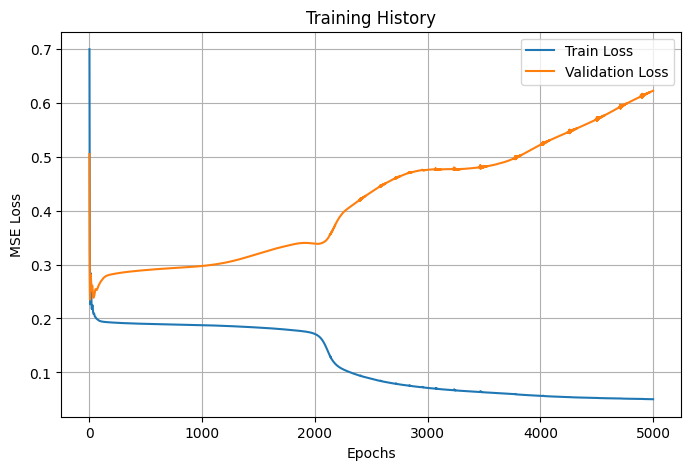

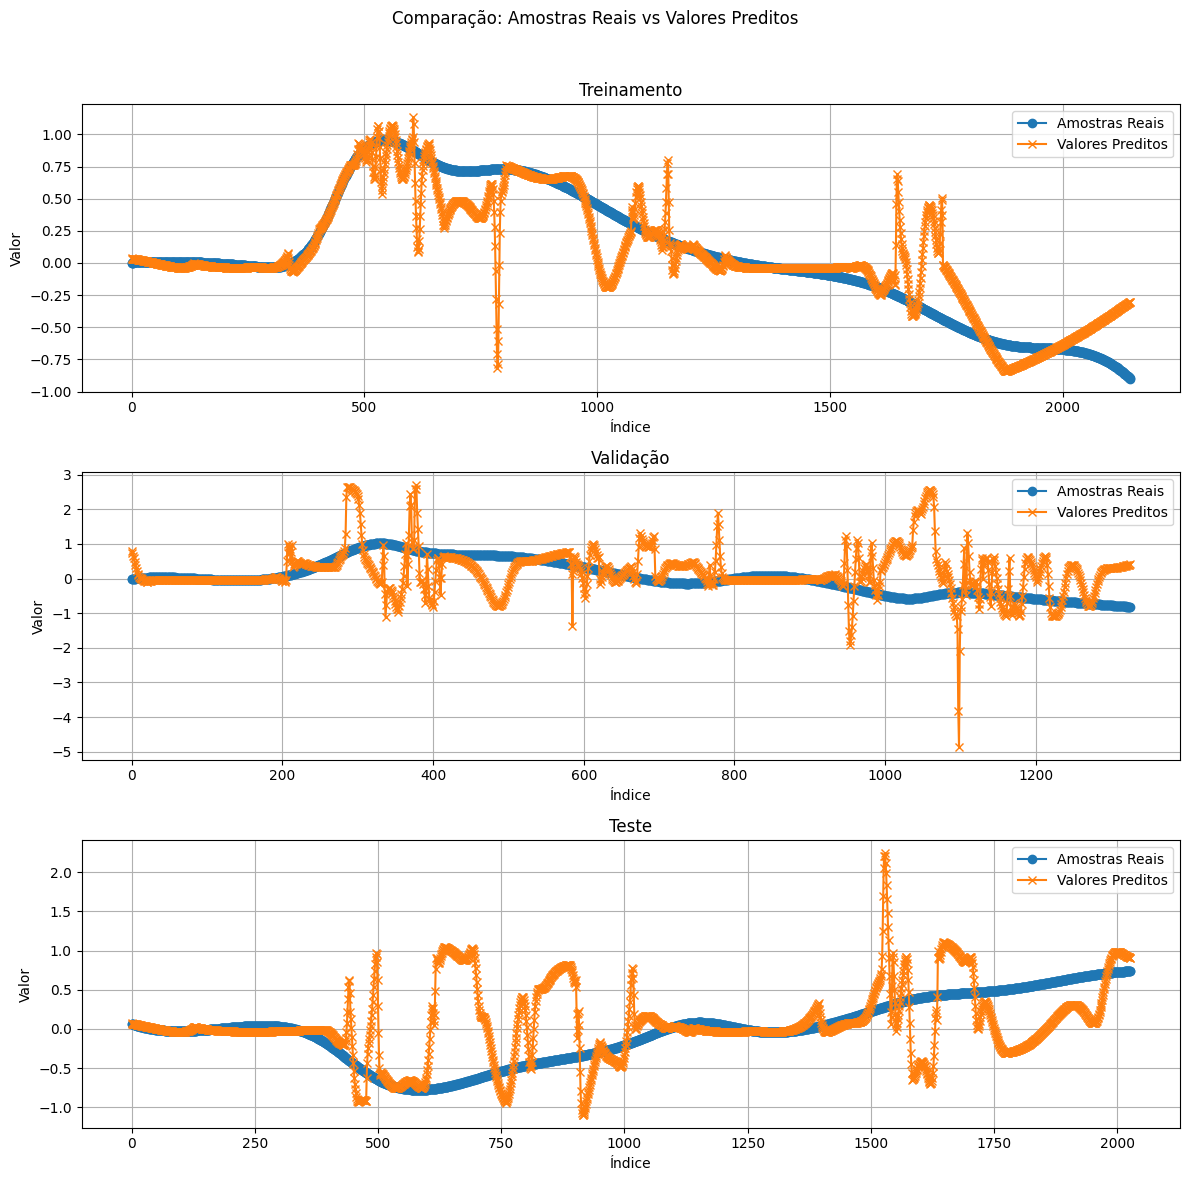

{'Training': {'R2': 0.7912201871066782,
  'MSE': 0.05034305777146148,
  'RMSE': 0.22437258694292733,
  'MAPE': 1.9116009270449226},
 'Validation': {'R2': -1.6997588739943752,
  'MSE': 0.6220552846090357,
  'RMSE': 0.7887048146227051,
  'MAPE': 4.650525495803946},
 'Test': {'R2': -0.8404481353187758,
  'MSE': 0.30341568932643576,
  'RMSE': 0.5508318158262427,
  'MAPE': 1.9787209583393217}}

In [6]:
import keras

complex_dense_RNN_grad  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])

custom_train_model(complex_dense_RNN_grad)

c:\Users\João Vitor\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iniciando o treinamento manual com derivada automática (Early Stopping com paciência=50)...
Epoch 1/5000, Train Loss: 0.2743, Val Loss: 0.2348 (Melhora há 0 épocas)
Epoch 52/5000, Train Loss: 0.1995, Val Loss: 0.2609 (Melhora há 50 épocas)
Early stopping! Validação não melhorou por 50 épocas.
Melhor Val Loss: 0.2338 na época 2
Pesos do modelo restaurados para a melhor época.
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Training Metrics:
  R2: -0.0018
  MSE: 0.2416
  RMSE: 0.4915
  MAPE: 2.0846

Validation Metrics:
  R2: -0.0148
  MSE: 0.2338
  RMSE: 0.4835
  MAPE: 1.3614

Test Metrics:
  R2: -0.0448
  MSE: 0.1723
  RMSE: 0.4150
  MAPE: 1.6183


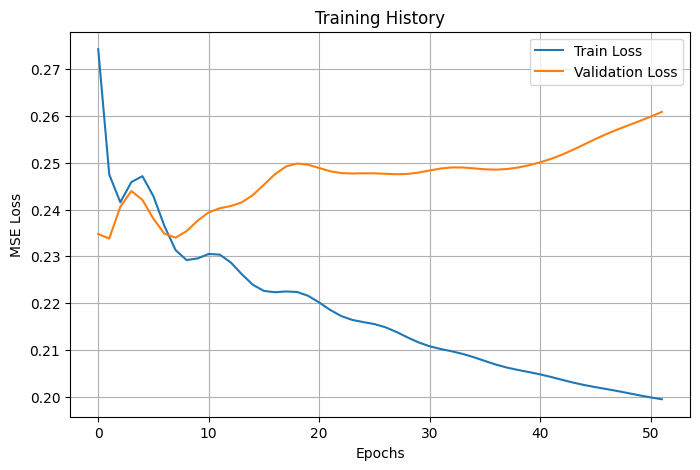

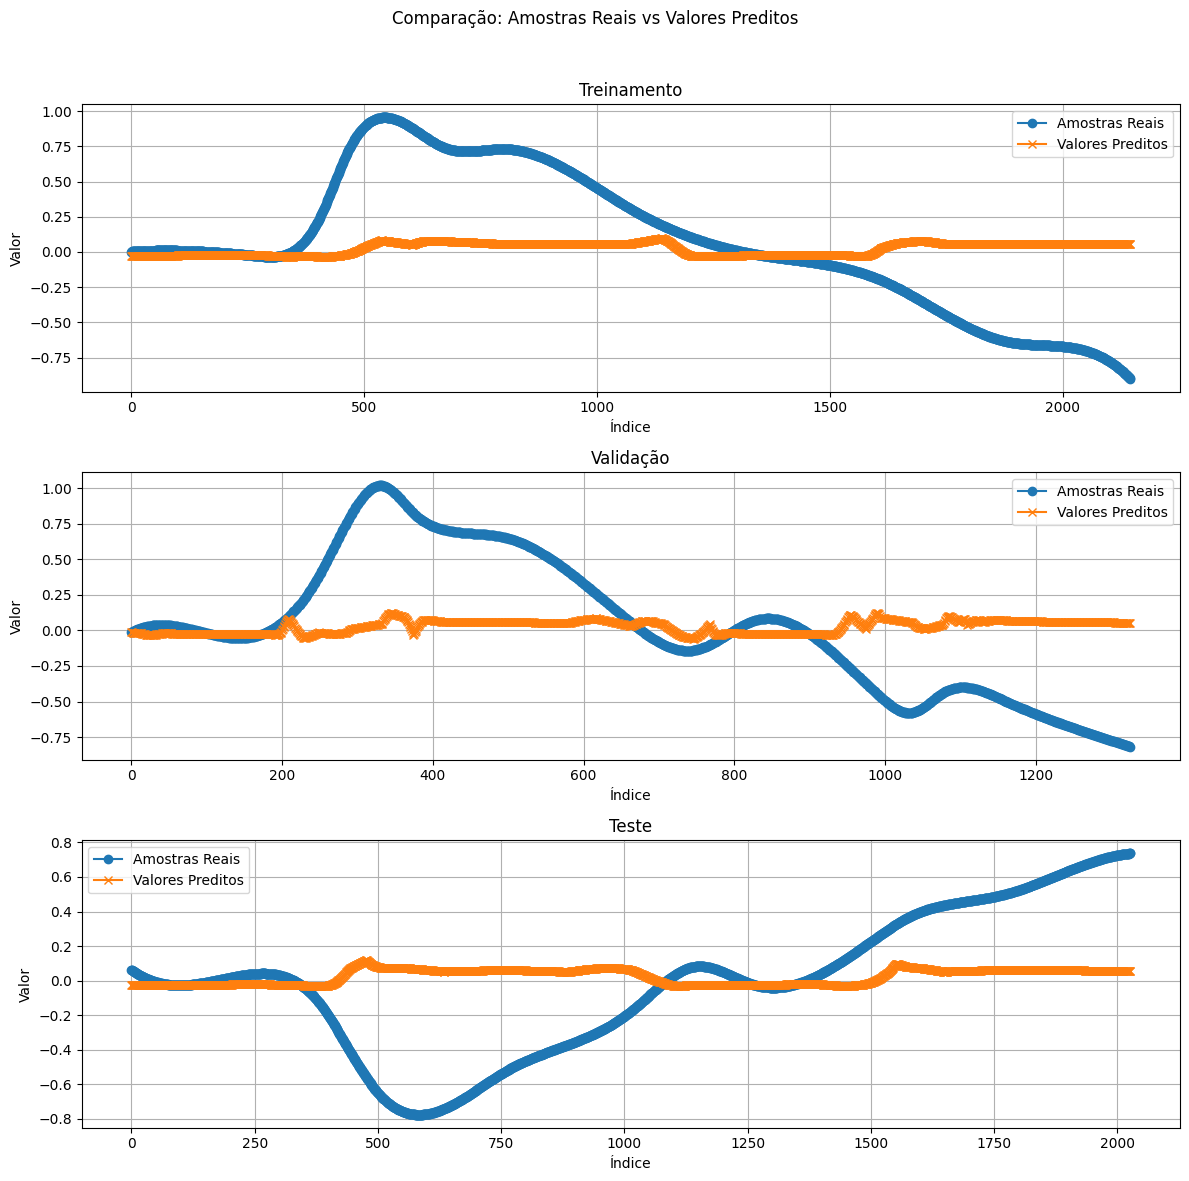

{'Training': {'R2': -0.001836136390968468,
  'MSE': 0.24157265873994635,
  'RMSE': 0.4915004158085183,
  'MAPE': 2.084646753771192},
 'Validation': {'R2': -0.014793754473317433,
  'MSE': 0.23382007328099136,
  'RMSE': 0.4835494527770571,
  'MAPE': 1.3614219352965182},
 'Test': {'R2': -0.04483902602661116,
  'MSE': 0.172251826733556,
  'RMSE': 0.41503232010718877,
  'MAPE': 1.6183242417584152}}

In [10]:
complex_dense_RNN_ES  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])
custom_train_model_with_es(complex_dense_RNN_ES)

In [38]:
import keras

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[2, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step

Training Metrics:
  R2: 0.9215
  MSE: 0.0189
  RMSE: 0.1376
  MAPE: 1.7929

Validation Metrics:
  R2: -2.0792
  MSE: 0.7095
  RMSE: 0.8423
  MAPE: 5.8935

Test Metrics:
  R2: -6.0635
  MSE: 1.1645
  RMSE: 1.0791
  MAPE: 2.3699


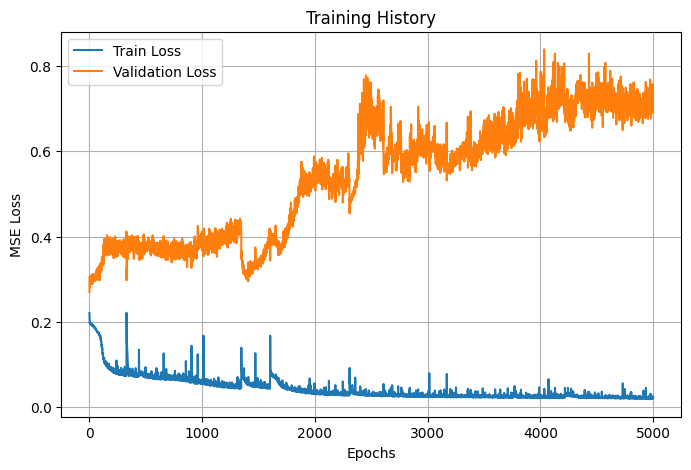

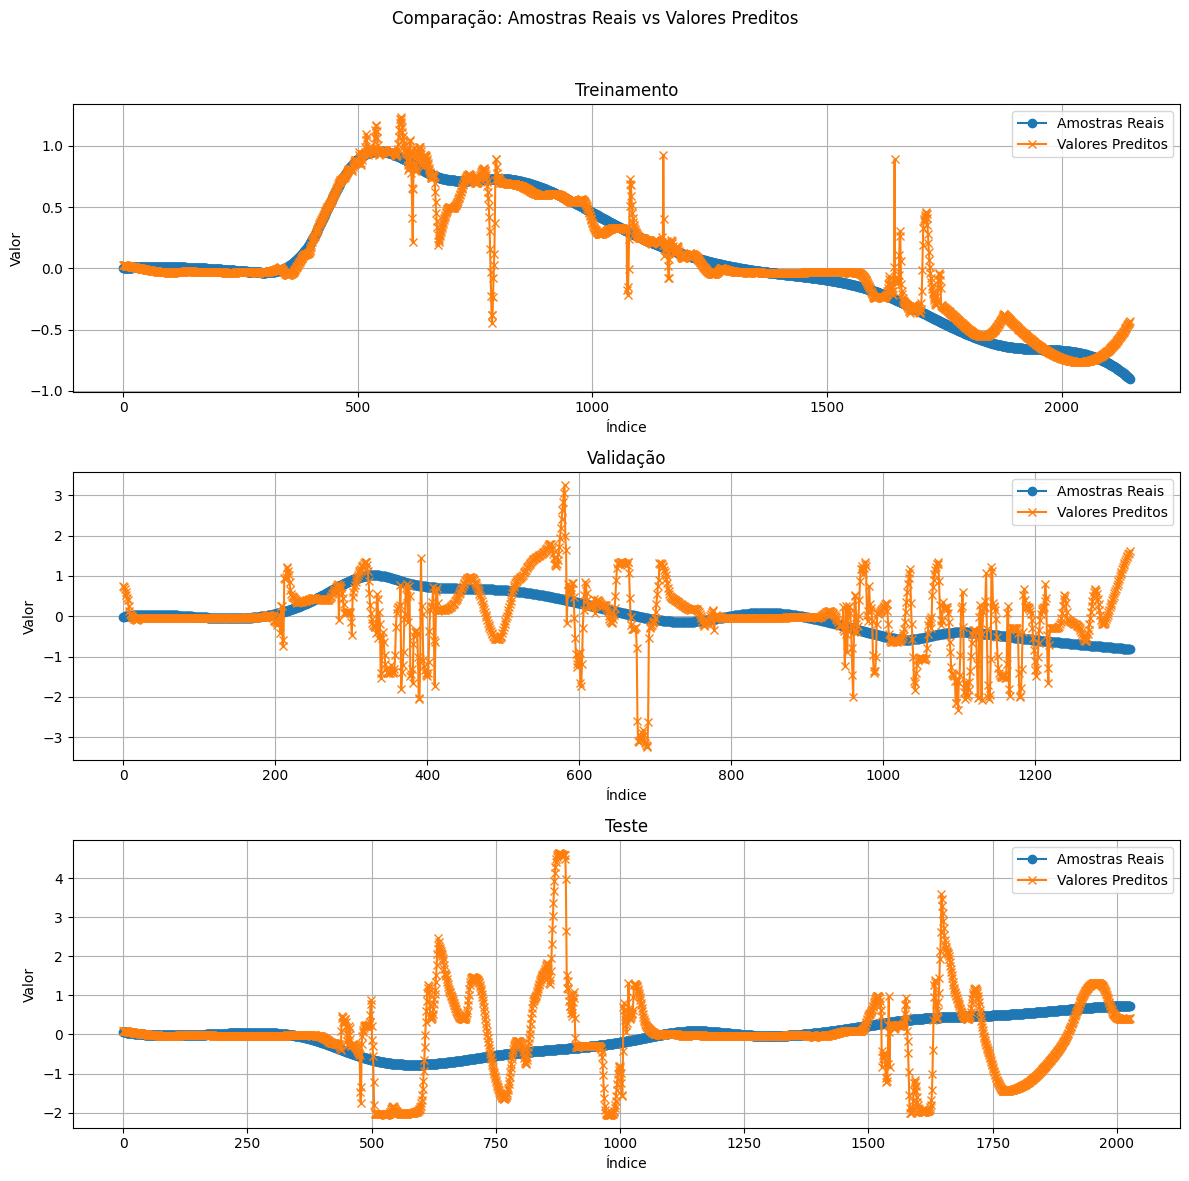

{'Training': {'R2': 0.9214721481038477,
  'MSE': 0.018935413965030998,
  'RMSE': 0.1376060099161043,
  'MAPE': 1.792917335693741},
 'Validation': {'R2': -2.079158168410642,
  'MSE': 0.7094732160183688,
  'RMSE': 0.8423023305312463,
  'MAPE': 5.893541771526633},
 'Test': {'R2': -6.06354276616901,
  'MSE': 1.164493395035398,
  'RMSE': 1.0791169515096117,
  'MAPE': 2.369891600731235}}

In [39]:
compile_model(complex_dense_RNN)

In [ ]:
def pinn_loss(y_true, y_pred, x, R = 0.034, L = 0.123, Ts = 0.07):
    #Calculo da derivada da saida
    y_pred
